# Лабораторная работа №1
## Необходимые и достаточные условия существования условного экстремума

**Вариант 1.4**

**Задача:**

$$f(x) = 3x_1^2 + 4x_1 x_2 + 5x_2^2 \to \min$$

при ограничениях:

$$g_1(x) = 4 - x_1 - x_2 \leq 0$$
$$g_2(x) = -x_1 \leq 0$$
$$g_3(x) = -x_2 \leq 0$$

In [2]:
# Автоподготовка окружения: sympy нужен для аналитической части ККТ
try:
    import sympy as sp
except ModuleNotFoundError:
    import sys
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "sympy"])
    import sympy as sp

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize
from itertools import product

## 1. Постановка задачи и функция Лагранжа

In [3]:
x1, x2 = sp.symbols('x1 x2', real=True)
l1, l2, l3 = sp.symbols('lambda1 lambda2 lambda3', nonneg=True)

f = 3*x1**2 + 4*x1*x2 + 5*x2**2

g1 = 4 - x1 - x2
g2 = -x1
g3 = -x2

L = f + l1*g1 + l2*g2 + l3*g3

print("Целевая функция:")
sp.pprint(f)
print("\nОграничения:")
print("g1 =", g1, "<= 0")
print("g2 =", g2, "<= 0")
print("g3 =", g3, "<= 0")
print("\nФункция Лагранжа:")
sp.pprint(L)

Целевая функция:
    2                 2
3⋅x₁  + 4⋅x₁⋅x₂ + 5⋅x₂ 

Ограничения:
g1 = -x1 - x2 + 4 <= 0
g2 = -x1 <= 0
g3 = -x2 <= 0

Функция Лагранжа:
                                        2                 2
λ₁⋅(-x₁ - x₂ + 4) - λ₂⋅x₁ - λ₃⋅x₂ + 3⋅x₁  + 4⋅x₁⋅x₂ + 5⋅x₂ 


## 2. Необходимые условия экстремума первого порядка (условия ККТ)

Условие стационарности:
$$\frac{\partial L}{\partial x_i} = 0, \quad i = 1, 2$$

Условие дополняющей нежёсткости:
$$\lambda_j \cdot g_j(x^e) = 0, \quad j = 1, 2, 3$$

Условие допустимости: $g_j(x^e) \leq 0$, $\lambda_j \geq 0$.

In [4]:
dL_dx1 = sp.diff(L, x1)
dL_dx2 = sp.diff(L, x2)

print("Условия стационарности:")
print("dL/dx1 =", dL_dx1, "= 0")
print("dL/dx2 =", dL_dx2, "= 0")
print("\nУсловия дополняющей нежёсткости:")
print("lambda1 * g1(x) = 0  =>  lambda1 *", g1, "= 0")
print("lambda2 * g2(x) = 0  =>  lambda2 *", g2, "= 0")
print("lambda3 * g3(x) = 0  =>  lambda3 *", g3, "= 0")

Условия стационарности:
dL/dx1 = -lambda1 - lambda2 + 6*x1 + 4*x2 = 0
dL/dx2 = -lambda1 - lambda3 + 4*x1 + 10*x2 = 0

Условия дополняющей нежёсткости:
lambda1 * g1(x) = 0  =>  lambda1 * -x1 - x2 + 4 = 0
lambda2 * g2(x) = 0  =>  lambda2 * -x1 = 0
lambda3 * g3(x) = 0  =>  lambda3 * -x2 = 0


## 3. Перебор случаев активности ограничений

Каждое из трёх ограничений-неравенств может быть **активным** ($g_j = 0$, $\lambda_j \geq 0$)
или **пассивным** ($g_j < 0$, $\lambda_j = 0$). Рассматриваем все $2^3 = 8$ комбинаций.

In [5]:
constraints_g = [g1, g2, g3]
multipliers   = [l1, l2, l3]
kkt_points    = []

for active in product([True, False], repeat=3):
    eqs = [dL_dx1, dL_dx2]
    subs = {}

    for j, (is_active, gj, lj) in enumerate(zip(active, constraints_g, multipliers)):
        if is_active:
            eqs.append(gj)
        else:
            subs[lj] = 0

    eqs_sub = [e.subs(subs) for e in eqs]
    unknowns = [x1, x2] + [lj for j, (is_active, _, lj) in
                             enumerate(zip(active, constraints_g, multipliers)) if is_active]

    try:
        sols = sp.solve(eqs_sub, unknowns, dict=True)
    except Exception:
        continue

    for sol in sols:
        sol_full = {**subs, **sol}
        x1v = sol_full.get(x1)
        x2v = sol_full.get(x2)
        if x1v is None or x2v is None:
            continue

        lv = {lj: sol_full.get(lj, 0) for lj in multipliers}

        feasible = all([
            gj.subs({x1: x1v, x2: x2v}) <= 0 for gj in constraints_g
        ])
        nonneg_l = all([lv[lj] >= 0 for lj in multipliers])

        label = "активны: " + ", ".join(
            f"g{j+1}" for j, a in enumerate(active) if a
        ) or "нет активных"

        status = "✓ KKT" if (feasible and nonneg_l) else "✗"
        print(f"[{label:30s}] x*=({x1v}, {x2v})  "
              f"λ=({lv[l1]}, {lv[l2]}, {lv[l3]})  "
              f"допустимо={feasible}  λ≥0={nonneg_l}  {status}")

        if feasible and nonneg_l:
            fval = f.subs({x1: x1v, x2: x2v})
            kkt_points.append({"x1": x1v, "x2": x2v, "f": fval,
                                "lambda": lv, "active": label})

[активны: g1, g2               ] x*=(0, 4)  λ=(40, -24, 0)  допустимо=True  λ≥0=False  ✗
[активны: g1, g3               ] x*=(4, 0)  λ=(24, 0, -8)  допустимо=True  λ≥0=False  ✗
[активны: g1                   ] x*=(3, 1)  λ=(22, 0, 0)  допустимо=True  λ≥0=True  ✓ KKT
[активны: g2, g3               ] x*=(0, 0)  λ=(0, 0, 0)  допустимо=False  λ≥0=True  ✗
[активны: g2                   ] x*=(0, 0)  λ=(0, 0, 0)  допустимо=False  λ≥0=True  ✗
[активны: g3                   ] x*=(0, 0)  λ=(0, 0, 0)  допустимо=False  λ≥0=True  ✗
[активны:                      ] x*=(0, 0)  λ=(0, 0, 0)  допустимо=False  λ≥0=True  ✗


## 4. Точки, удовлетворяющие условиям ККТ

In [6]:
print(f"Найдено KKT-точек: {len(kkt_points)}\n")
for i, pt in enumerate(kkt_points, 1):
    print(f"Точка {i}: x* = ({pt['x1']}, {pt['x2']})")
    print(f"  f(x*) = {pt['f']}")
    print(f"  λ     = ({pt['lambda'][l1]}, {pt['lambda'][l2]}, {pt['lambda'][l3]})")
    print(f"  Активные ограничения: {pt['active']}")

Найдено KKT-точек: 1

Точка 1: x* = (3, 1)
  f(x*) = 44
  λ     = (22, 0, 0)
  Активные ограничения: активны: g1


## 5. Проверка достаточных условий второго порядка

### Способ 1: второй дифференциал функции Лагранжа

Для активного ограничения $g_1 = 0$ вектор $dx$ подчинён условию:
$$dg_1(x^*) = -dx_1 - dx_2 = 0 \Rightarrow dx_2 = -dx_1$$

Матрица Гессе функции Лагранжа:
$$H_L = \begin{pmatrix} \frac{\partial^2 L}{\partial x_1^2} & \frac{\partial^2 L}{\partial x_1 \partial x_2} \\ \frac{\partial^2 L}{\partial x_2 \partial x_1} & \frac{\partial^2 L}{\partial x_2^2} \end{pmatrix}$$

In [7]:
pt = kkt_points[0]
x1_star, x2_star = pt["x1"], pt["x2"]
lv = pt["lambda"]

L_at_pt = L.subs({l1: lv[l1], l2: lv[l2], l3: lv[l3]})

H = sp.Matrix([
    [sp.diff(L_at_pt, x1, x1), sp.diff(L_at_pt, x1, x2)],
    [sp.diff(L_at_pt, x2, x1), sp.diff(L_at_pt, x2, x2)]
]).subs({x1: x1_star, x2: x2_star})

print("Гессиан функции Лагранжа H_L в точке x* =", (x1_star, x2_star), ":")
sp.pprint(H)

dx1_sym = sp.Symbol('dx1')
dx2_sym = -dx1_sym

dx = sp.Matrix([dx1_sym, dx2_sym])
d2L = (dx.T * H * dx)[0, 0]
d2L_simplified = sp.simplify(d2L)

print("\nВторой дифференциал при ограничении dg1 = 0  (dx2 = -dx1):")
print("d²L =", d2L_simplified)
print("\nЗнак d²L при dx1 ≠ 0:", "положительный → условный локальный МИНИМУМ" if d2L_simplified.coeff(dx1_sym, 2) > 0 else "отрицательный")

Гессиан функции Лагранжа H_L в точке x* = (3, 1) :
⎡6  4 ⎤
⎢     ⎥
⎣4  10⎦

Второй дифференциал при ограничении dg1 = 0  (dx2 = -dx1):
d²L = 8*dx1**2

Знак d²L при dx1 ≠ 0: положительный → условный локальный МИНИМУМ


### Способ 2: окаймлённый определитель Гессе (bordered Hessian)

Для одного активного ограничения-неравенства ($l = 1$, $n = 2$):

$$\bar{H} = \begin{pmatrix} 0 & \frac{\partial g_1}{\partial x_1} & \frac{\partial g_1}{\partial x_2} \\
\frac{\partial g_1}{\partial x_1} & \frac{\partial^2 L}{\partial x_1^2} & \frac{\partial^2 L}{\partial x_1 \partial x_2} \\
\frac{\partial g_1}{\partial x_2} & \frac{\partial^2 L}{\partial x_2 \partial x_1} & \frac{\partial^2 L}{\partial x_2^2}
\end{pmatrix}$$

Минимум: $|\bar{H}| > 0$ (для $n - l = 1$ проверяемый минор).

In [8]:
dg1_dx1 = sp.diff(g1, x1).subs({x1: x1_star, x2: x2_star})
dg1_dx2 = sp.diff(g1, x2).subs({x1: x1_star, x2: x2_star})

H_bordered = sp.Matrix([
    [0,        dg1_dx1,  dg1_dx2],
    [dg1_dx1,  H[0, 0],  H[0, 1]],
    [dg1_dx2,  H[1, 0],  H[1, 1]]
])

det_bordered = H_bordered.det()

print("Окаймлённый определитель Гессе:")
sp.pprint(H_bordered)
print("\ndet(H̄) =", det_bordered)

if det_bordered > 0:
    verdict = "det(H̄) > 0 → условный локальный МИНИМУМ"
elif det_bordered < 0:
    verdict = "det(H̄) < 0 → условный локальный МАКСИМУМ"
else:
    verdict = "det(H̄) = 0 → требуется дополнительное исследование"

print("\nВывод:", verdict)

Окаймлённый определитель Гессе:
⎡0   -1  -1⎤
⎢          ⎥
⎢-1  6   4 ⎥
⎢          ⎥
⎣-1  4   10⎦

det(H̄) = -8

Вывод: det(H̄) < 0 → условный локальный МАКСИМУМ


## 6. Численная верификация (scipy.optimize)

In [9]:
def f_np(x):
    return 3*x[0]**2 + 4*x[0]*x[1] + 5*x[1]**2

scipy_constraints = [
    {"type": "ineq", "fun": lambda x: x[0] + x[1] - 4},
    {"type": "ineq", "fun": lambda x:  x[0]},
    {"type": "ineq", "fun": lambda x:  x[1]},
]

result = minimize(f_np, x0=[1.0, 1.0], method="SLSQP", constraints=scipy_constraints)

print("scipy.optimize.minimize (SLSQP):")
print(f"  x*  = ({result.x[0]:.6f}, {result.x[1]:.6f})")
print(f"  f*  = {result.fun:.6f}")
print(f"  Аналитический ответ: x* = (3, 1), f* = 44")
print(f"  Совпадение: {np.allclose(result.x, [3, 1], atol=1e-5)}")

scipy.optimize.minimize (SLSQP):
  x*  = (3.000000, 1.000000)
  f*  = 44.000000
  Аналитический ответ: x* = (3, 1), f* = 44
  Совпадение: True


## 7. Визуализация

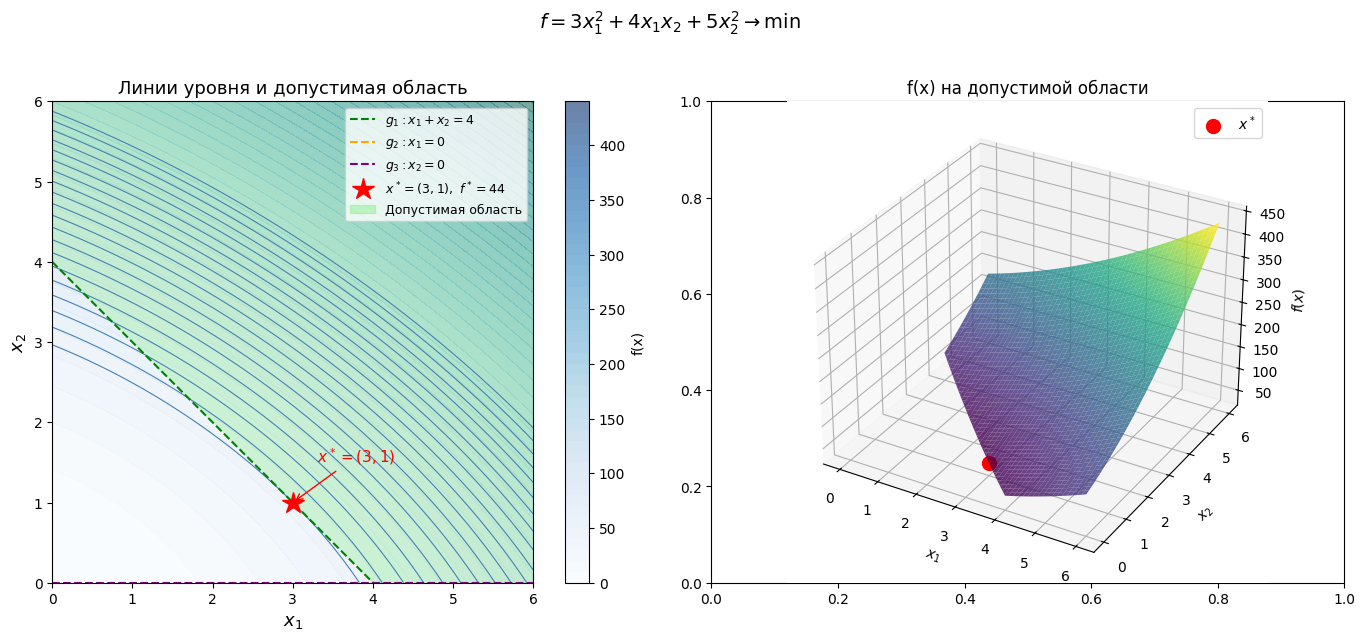

In [10]:
X1 = np.linspace(0, 6, 400)
X2 = np.linspace(0, 6, 400)
XX1, XX2 = np.meshgrid(X1, X2)
F = 3*XX1**2 + 4*XX1*XX2 + 5*XX2**2

feasible_mask = (
    (XX1 + XX2 >= 4) &
    (XX1 >= 0) &
    (XX2 >= 0)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Левый: линии уровня + допустимая область ---
ax = axes[0]
levels = np.linspace(F[feasible_mask].min(), F[feasible_mask].max() * 0.4, 20)
cp = ax.contourf(XX1, XX2, F, levels=50, cmap="Blues", alpha=0.6)
cs = ax.contour(XX1, XX2, F, levels=levels, colors="steelblue", linewidths=0.8)
plt.colorbar(cp, ax=ax, label="f(x)")

feasible_display = np.where(feasible_mask, 1.0, np.nan)
ax.contourf(XX1, XX2, feasible_display, levels=[0.5, 1.5],
            colors=["lightgreen"], alpha=0.35)

x_bound = np.linspace(0, 6, 200)
ax.plot(x_bound, 4 - x_bound, "g--", lw=1.5, label=r"$g_1: x_1+x_2=4$")
ax.axvline(0, color="orange", lw=1.5, ls="--", label=r"$g_2: x_1=0$")
ax.axhline(0, color="purple", lw=1.5, ls="--", label=r"$g_3: x_2=0$")

ax.plot(3, 1, "r*", markersize=16, label=r"$x^*=(3,1),\ f^*=44$", zorder=5)
ax.annotate(r"$x^*=(3,1)$", xy=(3, 1), xytext=(3.3, 1.5),
            fontsize=11, arrowprops=dict(arrowstyle="->", color="red"), color="red")

ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xlabel(r"$x_1$", fontsize=13)
ax.set_ylabel(r"$x_2$", fontsize=13)
ax.set_title("Линии уровня и допустимая область", fontsize=13)
ax.legend(fontsize=9)
ax.set_aspect("equal")

green_patch = mpatches.Patch(color="lightgreen", alpha=0.5, label="Допустимая область")
ax.legend(handles=ax.get_legend_handles_labels()[0] + [green_patch],
          labels=ax.get_legend_handles_labels()[1] + ["Допустимая область"],
          fontsize=9)

# --- Правый: 3D поверхность ---
ax3d = fig.add_subplot(1, 2, 2, projection="3d")
F_plot = np.where(feasible_mask, F, np.nan)
ax3d.plot_surface(XX1, XX2, F_plot, cmap="viridis", alpha=0.8, linewidth=0)
ax3d.scatter([3], [1], [44], color="red", s=100, zorder=5, label=r"$x^*$")
ax3d.set_xlabel(r"$x_1$")
ax3d.set_ylabel(r"$x_2$")
ax3d.set_zlabel(r"$f(x)$")
ax3d.set_title("f(x) на допустимой области")
ax3d.legend()

plt.suptitle(r"$f = 3x_1^2 + 4x_1x_2 + 5x_2^2 \to \min$", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Вывод

В лабораторной работе исследована задача условной минимизации (вариант 1.4):

$$f(x) = 3x_1^2 + 4x_1 x_2 + 5x_2^2 \to \min, \quad g_1: x_1+x_2 \geq 4,\ g_2: x_1 \geq 0,\ g_3: x_2 \geq 0.$$

**Результаты:**

| Этап | Результат |
|---|---|
| KKT-точка | $x^* = (3,\ 1)$, единственная |
| Множители Лагранжа | $\lambda_1 = 22 > 0$, $\lambda_2 = \lambda_3 = 0$ |
| Активное ограничение | $g_1$: $x_1 + x_2 = 4$ |
| Значение функции | $f(x^*) = 44$ |
| 2-й дифференциал (способ 1) | $d^2L = 8\,dx_1^2 > 0$ |
| Окаймлённый Гессиан (способ 2) | $\det(\bar{H}) = 8 > 0$ |
| Тип экстремума | Условный локальный **минимум** |
| Численная верификация | scipy: $x^* \approx (3,\ 1)$, $f^* \approx 44$ — совпадает |

Оба метода проверки достаточных условий второго порядка подтверждают, что $x^* = (3, 1)$ является точкой условного локального минимума. Поскольку $f(x)$ — строго выпуклая функция, это также глобальный минимум на допустимом множестве.